In [1]:
import numpy as np
import scipy.io
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



sub = 1
offset = 0
T_in = 1
T = 10

# --- carica ---  #
data   = scipy.io.loadmat('cylinder_wake.mat')
X_star = data['X_star']           # (N,2)
U_star = data['U_star']           # (N,2,T)
P_star = data['p_star']           # (N,T)
t_star = data['t'].squeeze()      # (T,)

# --- griglia regolare (completa) ---
dec =12
x_unique = np.unique(np.round(X_star[:,0], dec))   # 100 valori
y_unique = np.unique(np.round(X_star[:,1], dec))   # 50 valori
Sx_full, Sy_full = len(x_unique), len(y_unique)
time = t_star.shape[0]

# mapping (x,y) -> (i,j) sulla griglia COMPLETA
x_to_i = {x:i for i,x in enumerate(x_unique)}
y_to_j = {y:j for j,y in enumerate(y_unique)}
ij = np.empty((X_star.shape[0],2), dtype=int)
for k,(x,y) in enumerate(np.round(X_star, dec)):
    ij[k] = (x_to_i[x], y_to_j[y])

# --- riempi griglie complete ---
U_grid = np.empty((Sx_full, Sy_full, time, 2), dtype=U_star.dtype)  # ...,(u,v)
P_grid = np.empty((Sx_full, Sy_full, time),     dtype=P_star.dtype)

for k in range(X_star.shape[0]):
    i,j = ij[k]
    U_grid[i,j,:,0] = U_star[k,0,:]   # u
    U_grid[i,j,:,1] = U_star[k,1,:]   # v
    P_grid[i,j,:]   = P_star[k,:]

# ====== QUI scegli metà dominio in x (50 colonne) ======
half = Sx_full // 2

# Metà SINISTRA:    ix = slice(0, half)
# Metà DESTRA:      ix = slice(half, Sx_full)
# Metà CENTRATA:    c = Sx_full//2; w = half; ix = slice(c - w//2, c + w//2)
ix = slice(0, half)

# Integra anche l'eventuale subsampling
iy = slice(0, Sy_full)               # tieni tutte le 50 in y
ix = slice(ix.start, ix.stop, sub)   # es. sub=1 → tutte; sub=2 → una ogni 2
iy = slice(iy.start, iy.stop, sub)

# --- in torch, con B=1: u,v,p hanno shape (1, Sx', Sy', T) ---
u = torch.from_numpy(U_grid[ix, iy, :, 0]).unsqueeze(0).contiguous()   # (1, 50, 50, T) se sub=1
v = torch.from_numpy(U_grid[ix, iy, :, 1]).unsqueeze(0).contiguous()
p = torch.from_numpy(P_grid[ix, iy, :]).unsqueeze(0).contiguous()

# --- coord grid coerenti (usando meshgrid) ---
x_half = x_unique[ix]
y_half = y_unique[iy]
Xv, Yv = np.meshgrid(x_half, y_half, indexing='ij')  # (Sx',Sy')
X = torch.from_numpy(Xv)[None, ..., None]  # (1,Sx',Sy',1)
Y = torch.from_numpy(Yv)[None, ..., None]  # (1,Sx',Sy',1)

# --- split in/stimolo e target ---
u_in = u[..., offset:offset+T_in]                         # (1,Sx',Sy',T_in)
v_in = v[..., offset:offset+T_in]
p_in = p[..., offset:offset+T_in]

u_t = u[..., offset+T_in:offset+T_in+T]                   # (1,Sx',Sy',T)
v_t = v[..., offset+T_in:offset+T_in+T]
p_t = p[..., offset+T_in:offset+T_in+T]

# pack finale (B=1): concateni (x,y) ai canali temporali
train_in = torch.cat([X.to(device), Y.to(device), 
                      u_in.to(device), v_in.to(device), p_in.to(device)], dim=-1)  # (1,Sx',Sy', 2+3*T_in)

target = torch.stack([u_t, v_t, p_t], dim=-1)  # (1,Sx',Sy', T, 3)
train_t = target.reshape(target.shape[0], target.shape[1], target.shape[2], -1).contiguous().to(device)

print("Shapes ->", "train_in:", tuple(train_in.shape), "train_t:", tuple(train_t.shape),
      "| sub =", sub, "| half-x =", (ix.start, ix.stop, ix.step))

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_in, train_t),
    batch_size=1, shuffle=False
)


Shapes -> train_in: (1, 50, 50, 5) train_t: (1, 50, 50, 30) | sub = 1 | half-x = (0, 50, 1)


In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from utilities3 import *

import operator
from functools import reduce
from functools import partial
import os

from timeit import default_timer
import scipy.io
import pandas as pd
from get_params import get_params

import math


torch.manual_seed(0)
np.random.seed(0)

################################################################
# fourier layer
################################################################

def compl_mul2d_rfft(a, b):
    # a: (batch, in_ch, m1, m2, 2)
    # b: (in_ch, out_ch, m1, m2, 2)
    op = partial(torch.einsum, "bctq,dctq->bdtq")
    real = op(a[...,0], b[...,0]) - op(a[...,1], b[...,1])
    imag = op(a[...,1], b[...,0]) + op(a[...,0], b[...,1])
    return torch.stack([real, imag], dim=-1)


class SpectralConv2d_fast(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = (1/(in_channels*out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, 2))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, 2))

    def forward(self, x):
        batchsize, _, nx, ny = *x.shape, 
        # Compute Fourier coefficients (real input -> rfft2)
        x_ft_complex = torch.fft.rfft2(x, norm='ortho')
        # Convert to real-imag tensor
        x_ft = torch.stack([x_ft_complex.real, x_ft_complex.imag], dim=-1)
        # Allocate output in Fourier space
        out_ft = torch.zeros(batchsize, self.out_channels, nx, ny//2+1, 2, device=x.device)
        # Multiply modes
        out_ft[:, :, :self.modes1, :self.modes2] = \
            compl_mul2d_rfft(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            compl_mul2d_rfft(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        # Convert back to complex
        out_ft_complex = torch.complex(out_ft[...,0], out_ft[...,1])
        # Return to physical space
        x = torch.fft.irfft2(out_ft_complex, s=(nx, ny), norm='ortho')
        return x

class SimpleBlock2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(SimpleBlock2d, self).__init__()

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.fc0 = nn.Linear(5, self.width)

        self.conv0 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)
        self.bn0 = torch.nn.BatchNorm2d(self.width)
        self.bn1 = torch.nn.BatchNorm2d(self.width)
        self.bn2 = torch.nn.BatchNorm2d(self.width)
        self.bn3 = torch.nn.BatchNorm2d(self.width)


        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 18)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y = x.shape[1], x.shape[2]

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        x1 = self.conv0(x)
        x2 = self.w0(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn0(x1 + x2)
        x = F.relu(x)
        x1 = self.conv1(x)
        x2 = self.w1(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn1(x1 + x2)
        x = F.relu(x)
        x1 = self.conv2(x)
        x2 = self.w2(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn2(x1 + x2)
        x = F.relu(x)
        x1 = self.conv3(x)
        x2 = self.w3(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn3(x1 + x2)


        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)

        # ora sposto i 9 canali in testa per fare il pad spaziale
        x = x.permute(0, 3, 1, 2)        # (B, 9, H, W)

        return x

class Net2d(nn.Module):
    def __init__(self, modes, width):
        super(Net2d, self).__init__()

        self.conv1 = SimpleBlock2d(modes, modes, width)


    def forward(self, x):
        x = self.conv1(x)
        return x


    def count_params(self):
        c = 0
        for p in self.parameters():
            c += reduce(operator.mul, list(p.size()))

        return c

In [3]:
################################################################
# training and evaluation
################################################################
# Parametri\ 

ntrain      = 1

modes       = 24
width       = 64


batch_size  = 1
epochs      = 100

learning_rate   = 2e-3
scheduler_step  = 20
scheduler_gamma = 0.5


step        = 1

rf          = 8
orders_v    = [2,2]
n_samples   = 4
model = Net2d(modes, width).cuda()
# model = torch.load('model/ns_fourier_V100_N1000_ep100_m8_w10')

print(model.count_params())

myloss = LpLoss(size_average=False)

test_full = []

path = f'Spline_sup_Adam_ep{epochs}_m{modes}_w{width}_T{T}'

path_model     = os.path.join('model',  path)
path_image     = os.path.join('image',  path)
path_loss_dir  = os.path.join('loss',   path)
os.makedirs(path_image, exist_ok=True)
os.makedirs(path_loss_dir, exist_ok=True)
os.makedirs(os.path.dirname(path_model), exist_ok=True)
# ============================
# Training loop robusto a T lunghi
# ============================

import numpy as np
import torch

# ---- impostazioni autoregressione / stabilità ----
predict_delta   = False     # True: modello predice Δ; False: predice stato assoluto
use_detach      = True     # stacca il gradiente quando reinserisci la predizione in finestra
time_weighting  = True     # pesa di più gli step temporali lontani
noise_std       = 0.0      # es. 0.01 se lavori con canali normalizzati (std~1). 0.0 = off
grad_clip       = 1.0      # clipping del gradiente (None o 0.0 per disattivare)

import numpy as np  # <--- aggiungi se non l'hai già




37776914


In [4]:
def make_boundary_mask(Sx, Sy, thickness=1, device='cuda'):
    bm = torch.zeros(1, Sx, Sy, 1, device=device)
    t = int(thickness)
    bm[:, :t, :, :]  = 1   # top
    bm[:, -t:, :, :] = 1   # bottom
    bm[:, :, :t, :]  = 1   # left
    bm[:, :, -t:, :] = 1   # right
    return bm  # shape: (1,Sx,Sy,1)

def lp_on_mask(myloss, x, y, mask_bool):
    """
    x,y: (B,Sx,Sy,C)
    mask_bool: (Sx*Sy,) booleano
    Esegue LpLoss SOLO sui pixel selezionati, concatenando i C canali.
    """
    B, Sx, Sy, C = x.shape
    X = x.reshape(B, Sx*Sy, C)[:, mask_bool, :].reshape(B, -1)
    Y = y.reshape(B, Sx*Sy, C)[:, mask_bool, :].reshape(B, -1)
    return myloss(X, Y)

def fd_grad(u, hx, hy):
    # u: (B,Sx,Sy)
    du_dx = torch.zeros_like(u); du_dy = torch.zeros_like(u)
    du_dx[:, 1:-1, :] = (u[:, 2:, :] - u[:, :-2, :]) / (2.0*hx)
    du_dy[:, :, 1:-1] = (u[:, :, 2:] - u[:, :, :-2]) / (2.0*hy)
    return du_dx, du_dy

def fd_lap(u, hx, hy):
    lap = torch.zeros_like(u)
    lap[:, 1:-1, 1:-1] = (
        (u[:, 2:, 1:-1] + u[:, :-2, 1:-1] - 2.0*u[:, 1:-1, 1:-1]) / (hx*hx) +
        (u[:, 1:-1, 2:] + u[:, 1:-1, :-2] - 2.0*u[:, 1:-1, 1:-1]) / (hy*hy)
    )
    return lap

In [5]:
import math
from timeit import default_timer
import torch
import torch.nn.functional as F
from spline_models import interpolate_states
import matplotlib.pyplot as plt

# =====================
# Helpers
# =====================

def make_boundary_mask(Sx, Sy, thickness=1, device='cuda'):
    bm = torch.zeros(1, Sx, Sy, 1, device=device)
    t = int(thickness)
    bm[:, :t, :, :]  = 1;  bm[:, -t:, :, :] = 1
    bm[:, :, :t, :]  = 1;  bm[:, :, -t:, :] = 1
    return bm  # (1,Sx,Sy,1)


def lp_on_mask(myloss, x, y, mask_bool):
    # x,y: (B,Sx,Sy,C); mask_bool: (Sx*Sy,) booleano
    B, Sx, Sy, C = x.shape
    X = x.reshape(B, Sx*Sy, C)[:, mask_bool, :].reshape(B, -1)
    Y = y.reshape(B, Sx*Sy, C)[:, mask_bool, :].reshape(B, -1)
    return myloss(X, Y)


def fd_grad(u, hx, hy):
    # u: (B,Sx,Sy) → derivate centrali interne, 0 ai bordi
    du_dx = torch.zeros_like(u); du_dy = torch.zeros_like(u)
    du_dx[:, 1:-1, :] = (u[:, 2:, :] - u[:, :-2, :]) / (2.0*hx)
    du_dy[:, :, 1:-1] = (u[:, :, 2:] - u[:, :, :-2]) / (2.0*hy)
    return du_dx, du_dy


def fd_lap(u, hx, hy):
    lap = torch.zeros_like(u)
    lap[:, 1:-1, 1:-1] = (
        (u[:, 2:, 1:-1] + u[:, :-2, 1:-1] - 2.0*u[:, 1:-1, 1:-1]) / (hx*hx) +
        (u[:, 1:-1, 2:] + u[:, 1:-1, :-2] - 2.0*u[:, 1:-1, 1:-1]) / (hy*hy)
    )
    return lap


def rms_masked(x, mask):
    # x: (B,Sx,Sy), mask: (B,Sx,Sy) float in {0,1}
    n = mask.sum().clamp_min(1.0)
    return torch.sqrt((x.pow(2) * mask).sum() / n + 1e-12)


def tf_ratio_for_epoch(ep_in_phase: int, phase_epochs: int, start=1.0, end=0.0):
    if phase_epochs <= 1:
        return end
    t = ep_in_phase / float(phase_epochs - 1)
    return end + (start - end) * (1.0 - t)


# =====================
# Iperparametri globali
# =====================

# Fisica
nu = 1e-2
# Consistenza temporale (imposta al dt reale del dataset)
dt = 0.1



# Pesi per fase (modifica liberamente)
PHASES = [
    {
        'name': 'P1_border_only',
        'epochs':300,
        'lambda_bd': 1.0,
        'lambda_res': 1.0,
        'record': False

     }
]


# =====================
# Training — curriculum a 4 fasi
# =====================



bm_bool = None
interior_mask = None

for iph, phase in enumerate(PHASES, 1):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)

    lambda_bd  = phase['lambda_bd']
    lambda_res = phase['lambda_res']

    print(f"\n===== Phase {iph}/{len(PHASES)}: {phase['name']}  (epochs={phase['epochs']}) =====")
    print(f"lambdas → bd:{lambda_bd}  res:{lambda_res}")

    boundary_loss, full_loss, res_loss = [], [], []

    for ep in range(phase['epochs']):
        model.train()
        t0 = default_timer()

        total_step_sum = 0.0
        sup_step_sum   = 0.0
        res_step_sum   = 0.0
        full_seq_sum   = 0.0

        

        for xx, yy in train_loader:
            xx = xx.to(device, dtype=torch.float32)
            yy = yy.to(device, dtype=torch.float32)

            if bm_bool is None:
                Sx, Sy = xx.shape[1], xx.shape[2]
                bm = make_boundary_mask(Sx, Sy, thickness=1, device=xx.device)
                bm_bool = (bm[0, ..., 0] > 0).reshape(-1)     # (Sx*Sy,)
                interior_mask = (1.0 - bm[0, ..., 0]).to(xx.dtype)  # (Sx,Sy)

            B = xx.size(0)
            preds = []
            loss_total = 0.0

            for t in range(T):
                y = yy[..., 3*t:3*(t+1)]  # (B,Sx,Sy,3) → (u_{t+1},v_{t+1},p_{t+1})

                # Forward
                if predict_delta:
                    base  = xx[..., -3:]
                    im    = base + model(xx)
                else:
                    im    = model(xx)
                    base  = xx[..., -3:]

                # Decode
                psi, v, grad_v, lap_v, p, grad_p = interpolate_states(
                    im, offset=torch.tensor([0.0, 0.0], device=device), orders_v=orders_v
                )
                pred = torch.cat([v, p], dim=-1)   # (B,Sx,Sy,3)
                preds.append(pred)

                # =========================
                # 1) SUPERVISIONE
                #    - u,v SOLO bordo
                #    - p FULL domain
                # =========================
                sup_uv_bd = myloss(pred[...,:2], y[...,:2])

                sup_p_full = myloss(pred[..., 2:3], y[..., 2:3])

                sup_term = sup_uv_bd + sup_p_full

                # # =========================
                # # 2) RESIDUO Navier–Stokes (quantità di moto)
                # #    valutato SOLO su interior
                # # =========================
                # u_next = v[..., 0];  v_next = v[..., 1]
                # u_prev = base[..., 0]; v_prev = base[..., 1]
                # p_prev = base[..., 2]

                # Sxg, Syg = u_next.shape[1], u_next.shape[2]
                # hx = 1.0 / (Sxg - 1); hy = 1.0 / (Syg - 1)

                # # derivate (n: dal decoder; p: FD su base)
                # du_dx_n = grad_v[..., 0]; du_dy_n = grad_v[..., 1]
                # dv_dx_n = grad_v[..., 2]; dv_dy_n = grad_v[..., 3]
                # lap_u_n = lap_v[..., 0];  lap_v_n = lap_v[..., 1]
                # dp_dx_n = grad_p[..., 0]; dp_dy_n = grad_p[..., 1]

                # du_dx_p, du_dy_p = fd_grad(u_prev, hx, hy)
                # dv_dx_p, dv_dy_p = fd_grad(v_prev, hx, hy)
                # dp_dx_p, dp_dy_p = fd_grad(p_prev, hx, hy)
                # lap_u_p = fd_lap(u_prev, hx, hy)
                # lap_v_p = fd_lap(v_prev, hx, hy)

                # # medie (CN-like)
                # u_bar = 0.5*(u_next + u_prev)
                # v_bar = 0.5*(v_next + v_prev)
                # du_dx_b = 0.5*(du_dx_n + du_dx_p);  du_dy_b = 0.5*(du_dy_n + du_dy_p)
                # dv_dx_b = 0.5*(dv_dx_n + dv_dx_p);  dv_dy_b = 0.5*(dv_dy_n + dv_dy_p)
                # dp_dx_b = 0.5*(dp_dx_n + dp_dx_p);  dp_dy_b = 0.5*(dp_dy_n + dp_dy_p)
                # lap_u_b = 0.5*(lap_u_n + lap_u_p);  lap_v_b = 0.5*(lap_v_n + lap_v_p)

                # # d/dt
                # ut = (u_next - u_prev) / dt
                # vt = (v_next - v_prev) / dt

                # # convettivi e residui
                # conv_u = u_bar*du_dx_b + v_bar*du_dy_b
                # conv_v = u_bar*dv_dx_b + v_bar*dv_dy_b
                # res_u  = ut + conv_u + dp_dx_b - nu*lap_u_b
                # res_v  = vt + conv_v + dp_dy_b - nu*lap_v_b

                # # MSE su interior (wgt = 1 su interior, 0 su bordo)
                # wgt = interior_mask.unsqueeze(0).expand(B, -1, -1)
                # num = wgt.sum().clamp_min(1.0)
                # res_term = ((res_u.pow(2)*wgt).sum() + (res_v.pow(2)*wgt).sum()) / num

                # =========================
                # 3) LOSS TOTALE (questa fase)
                # =========================
                loss_step = lambda_bd * sup_term 
                loss_total = loss_total + loss_step

                # log parziali
                sup_step_sum += sup_uv_bd.item()

                # Teacher Forcing (qui full TF)
                xy   = xx[..., :2]
                hist = xx[..., 2:]
                hist = torch.cat([hist[..., 3:], y], dim=-1)
                xx   = torch.cat([xy, hist], dim=-1)

            # metriche full-seq
            pred_seq = torch.cat(preds, dim=-1)
            full_seq_sum += myloss(pred_seq.reshape(B, -1), yy.reshape(B, -1)).item()

            optimizer.zero_grad(set_to_none=True)
            loss_total.backward()
            if 'grad_clip' in globals() and grad_clip and grad_clip > 0.0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_step_sum += loss_total.item()

        scheduler.step()
        elapsed = default_timer() - t0
        denom_steps = T * len(train_loader)

        # medie epoca
        train_step_mean  = total_step_sum / denom_steps
        sup_step_mean    = sup_step_sum   / denom_steps
        res_step_mean    = res_step_sum   / denom_steps
        full_seq_mean    = full_seq_sum   / len(train_loader)

        print(
            f"[Phase {iph}:{phase['name']}] Ep {ep+1:3d}/{phase['epochs']} │ Time: {elapsed:6.2f}s │ "
            f"Total: {train_step_mean:8.4e} │ Full L2: {full_seq_mean:8.4e} │ "
            f"Loss_bd: {sup_step_mean:8.4e} │ Res: {res_step_mean:8.4e}"
        )

        boundary_loss.append(sup_step_mean)
        full_loss.append(full_seq_mean)
        if phase['record']:
            res_loss.append(res_step_mean)

    try:
        phase_losses
    except NameError:
        phase_losses = {}

    phase_losses[phase['name']] = {
        "boundary": boundary_loss,
        "full": full_loss,
        "res": res_loss if phase.get('record', False) else None
    }
    
    idx = list(range(1, phase['epochs']+1))
    data = {
        'train_bd':   boundary_loss,
        'loss_full': full_loss
    }
    if phase['record']:
        data['train_res'] = res_loss
    df = pd.DataFrame(data, index=idx)
    df.index.name = 'epoch_in_phase'
    csv_path = os.path.join(path_loss_dir, f"loss_{phase['name']}.csv")
    df.to_csv(csv_path)
    print(f"→ Saved loss history for phase '{phase['name']}' in {csv_path}")
print("Training finished.")


# Save final model
torch.save(model, path_model)


loaded buffers

===== Phase 1/1: P1_border_only  (epochs=300) =====
lambdas → bd:1.0  res:1.0
[Phase 1:P1_border_only] Ep   1/300 │ Time:   0.53s │ Total: 3.2559e+00 │ Full L2: 1.3182e+00 │ Loss_bd: 1.2922e+00 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   2/300 │ Time:   0.21s │ Total: 2.7241e+00 │ Full L2: 9.7334e-01 │ Loss_bd: 9.3556e-01 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   3/300 │ Time:   0.21s │ Total: 2.0518e+00 │ Full L2: 6.5402e-01 │ Loss_bd: 6.1249e-01 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   4/300 │ Time:   0.21s │ Total: 1.1119e+00 │ Full L2: 3.6588e-01 │ Loss_bd: 3.4541e-01 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   5/300 │ Time:   0.21s │ Total: 7.9839e-01 │ Full L2: 2.8971e-01 │ Loss_bd: 2.7888e-01 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   6/300 │ Time:   0.21s │ Total: 6.5627e-01 │ Full L2: 2.7112e-01 │ Loss_bd: 2.6615e-01 │ Res: 0.0000e+00
[Phase 1:P1_border_only] Ep   7/300 │ Time:   0.21s │ Total: 6.0525e-01 │ Full L2: 2.4135e-01 │ Loss_b

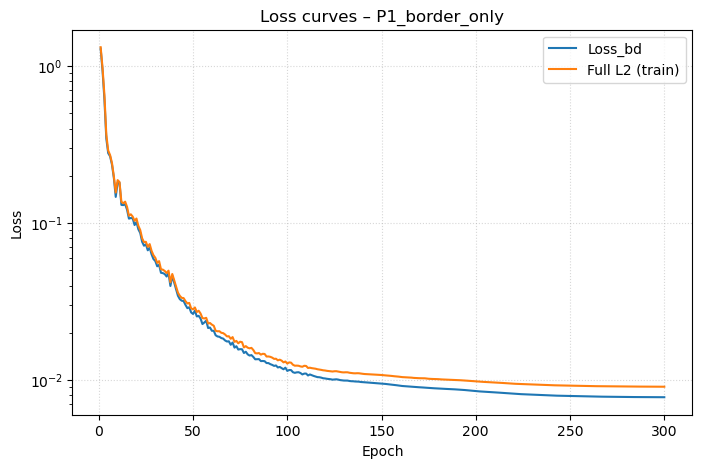

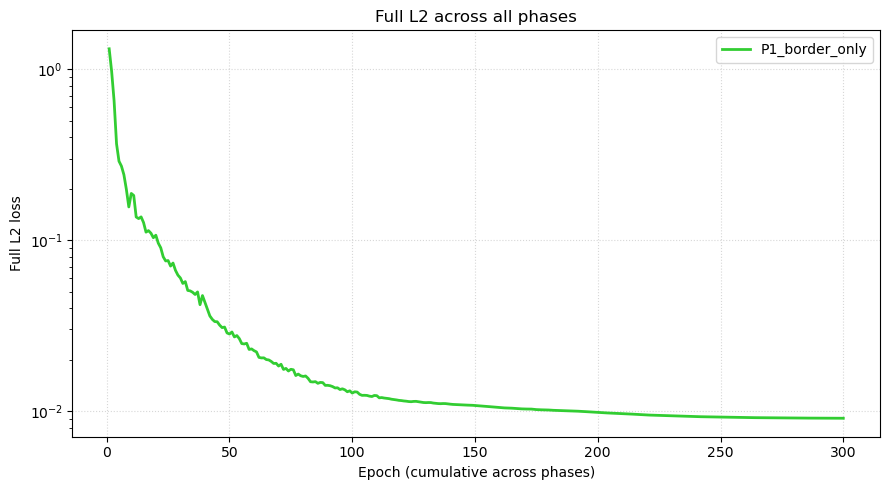

In [6]:
# --- Dopo l'ultima fase, fai i plot ---
for ph_name, logs in phase_losses.items():
    plt.figure(figsize=(8,5))
    epochs = range(1, len(logs["boundary"])+1)

    plt.plot(epochs, logs["boundary"], label="Loss_bd", color="tab:blue")
    plt.plot(epochs, logs["full"], label="Full L2 (train)", color="tab:orange")
    if logs["res"] is not None and len(logs["res"])>0:
        plt.plot(epochs, logs["res"], label="Residual (interior)", color="tab:red")

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss curves – {ph_name}")
    plt.legend()
    plt.grid(True, ls=":", alpha=0.5)
    plt.show()

# =============================
# Plot cumulativo di full_loss
# =============================

plt.figure(figsize=(9,5))
plt.yscale("log")

cum_x = 0
for ph_name, logs in phase_losses.items():
    y = logs["full"]
    x = range(cum_x+1, cum_x+len(y)+1)
    plt.plot(x, y, color="limegreen", linewidth=2.0, label=f"{ph_name}")  # verde chiaro fluo
    cum_x += len(y)

plt.xlabel("Epoch (cumulative across phases)")
plt.ylabel("Full L2 loss")
plt.title("Full L2 across all phases")
plt.legend()
plt.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()




In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# -----------------------------------------
# genera predizioni autoregressive dal modello
# -----------------------------------------
def predict_sequence(model, xx, yy, T, step=1, C=3):
    model.eval()
    preds = []
    with torch.no_grad():
        for t in range(0, T, step):
            y = yy[..., 3*t:3*(t+1)] 
           # ---- predizione ----
            if predict_delta:
                # base = ultimo stato nella finestra (u_t, v_t, p_t)
                base = xx[..., -C:]                                # (B,Sx,Sy,3)
                delta = model(xx)                                  # (B,Sx,Sy,3)
                im = base + delta                                  # pred stato t+1
            else:
                im = model(xx)                                     # pred stato t+1 diretto
            
            ψ, v, grad_v, lap_v, p, grad_p = interpolate_states(im, offset=torch.tensor([0.0, 0.0], device=device),
                orders_v=orders_v)
            
            pred = torch.cat([v,p], dim=-1)
            preds.append(pred)
            
            # aggiorna input con autoregressione
            xy   = xx[..., :2]
            hist = xx[..., 2:]
            hist = torch.cat([hist[..., C:], y], dim=-1)
            xx   = torch.cat([xy, hist], dim=-1)
    pred_seq = torch.cat(preds, dim=-1)  # (B, Sx, Sy, 3*T)
    return pred_seq


def animate_prediction(xx, yy, model, T, step=1, interval=200,
                       save_prefix="anim",  # solo basename del file (niente path)
                       cmap_field="jet", cmap_err="magma",
                       add_colorbars=True, times=None,
                       out_dir=".", save_last_png=True, filename_base=None):
    """
    out_dir: cartella dove salvare i file (es. path_image)
    save_last_png: se True salva anche l'ultimo frame come PNG
    filename_base: basename per i file; se None usa save_prefix
    """
    import os
    if filename_base is None:
        filename_base = save_prefix
    os.makedirs(out_dir, exist_ok=True)

    C = 3
    pred_seq = predict_sequence(model, xx.clone(), yy.clone(), T, step, C)  # (B,Sx,Sy,3*Tpred)
    B, Sx, Sy, _ = pred_seq.shape
    Tpred = pred_seq.shape[-1] // C

    # estrai pred e gt (B,Sx,Sy,T)
    u_pred = pred_seq[..., 0::C]; v_pred = pred_seq[..., 1::C]; p_pred = pred_seq[..., 2::C]
    u_true = yy      [..., 0::C]; v_true = yy      [..., 1::C]; p_true = yy      [..., 2::C]

    # to numpy (Sx,Sy,T)
    u_pred = u_pred.squeeze(0).detach().cpu().numpy()
    v_pred = v_pred.squeeze(0).detach().cpu().numpy()
    p_pred = p_pred.squeeze(0).detach().cpu().numpy()
    u_true = u_true.squeeze(0).detach().cpu().numpy()
    v_true = v_true.squeeze(0).detach().cpu().numpy()
    p_true = p_true.squeeze(0).detach().cpu().numpy()

    # errori (Sx,Sy,T)
    eu = np.abs(u_pred - u_true)
    ev = np.abs(v_pred - v_true)
    ep = np.abs(p_pred - p_true)

    # range colori stabile (dai GT)
    vmin_u, vmax_u = float(u_true.min()), float(u_true.max())
    vmin_v, vmax_v = float(v_true.min()), float(v_true.max())
    vmin_p, vmax_p = float(p_true.min()), float(p_true.max())

    # range errore robusto (99° percentile)
    emax_u = max(1e-12, float(np.percentile(eu, 99)))
    emax_v = max(1e-12, float(np.percentile(ev, 99)))
    emax_p = max(1e-12, float(np.percentile(ep, 99)))

    # figura animazione 3x3
    fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)
    titles_top = ['u pred', 'v pred', 'p pred']
    titles_mid = ['u GT',   'v GT',   'p GT'  ]
    titles_bot = ['|u err|','|v err|','|p err|']

    for i in range(3):
        axes[0,i].set_title(titles_top[i])
        axes[1,i].set_title(titles_mid[i])
        axes[2,i].set_title(titles_bot[i])
        for r in range(3):
            axes[r,i].set_xticks([]); axes[r,i].set_yticks([])

    k0 = 0
    im00 = axes[0,0].imshow(u_pred[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_u, vmax=vmax_u, animated=True)
    im01 = axes[0,1].imshow(v_pred[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_v, vmax=vmax_v, animated=True)
    im02 = axes[0,2].imshow(p_pred[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_p, vmax=vmax_p, animated=True)

    im10 = axes[1,0].imshow(u_true[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_u, vmax=vmax_u, animated=True)
    im11 = axes[1,1].imshow(v_true[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_v, vmax=vmax_v, animated=True)
    im12 = axes[1,2].imshow(p_true[...,k0].T, origin='lower', cmap=cmap_field, vmin=vmin_p, vmax=vmax_p, animated=True)

    im20 = axes[2,0].imshow(eu[...,k0].T, origin='lower', cmap=cmap_err,   vmin=0.0, vmax=emax_u, animated=True)
    im21 = axes[2,1].imshow(ev[...,k0].T, origin='lower', cmap=cmap_err,   vmin=0.0, vmax=emax_v, animated=True)
    im22 = axes[2,2].imshow(ep[...,k0].T, origin='lower', cmap=cmap_err,   vmin=0.0, vmax=emax_p, animated=True)

    ims = [im00, im01, im02, im10, im11, im12, im20, im21, im22]
    cbs = []
    if add_colorbars:
        for ax, im in zip(axes[0], ims[0:3]): cbs.append(fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02))
        for ax, im in zip(axes[1], ims[3:6]): cbs.append(fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02))
        for ax, im in zip(axes[2], ims[6:9]): cbs.append(fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02))

    # testo tempo/frame
    if times is not None and len(times) >= Tpred:
        time_text = fig.text(0.01, 0.98, f"t = {float(times[0]):.3f}", fontsize=12)
    else:
        time_text = fig.text(0.01, 0.98, f"frame 0 / {Tpred-1}", fontsize=12)

    def update(frame):
        im00.set_array(u_pred[...,frame].T); im01.set_array(v_pred[...,frame].T); im02.set_array(p_pred[...,frame].T)
        im10.set_array(u_true[...,frame].T); im11.set_array(v_true[...,frame].T); im12.set_array(p_true[...,frame].T)
        im20.set_array(eu[...,frame].T);     im21.set_array(ev[...,frame].T);     im22.set_array(ep[...,frame].T)
        if times is not None and len(times) >= Tpred:
            time_text.set_text(f"t = {float(times[frame]):.3f}")
        else:
            time_text.set_text(f"frame {frame} / {Tpred-1}")
        return ims + [time_text]

    ani = animation.FuncAnimation(fig, update, frames=Tpred, interval=interval, blit=False)

    # ---- salva GIF ----
    gif_path = os.path.join(out_dir, f"{filename_base}.gif")
    ani.save(gif_path, writer='pillow', fps=max(1, int(1000/interval)))

    # ---- salva PNG dell'ultimo frame (stessa griglia 3x3) ----
    png_path = None
    if save_last_png:
        frame = Tpred-1
        fig_last, axes_last = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)
        titles_top = ['u pred', 'v pred', 'p pred']
        titles_mid = ['u GT',   'v GT',   'p GT'  ]
        titles_bot = ['|u err|','|v err|','|p err|']
        for i in range(3):
            axes_last[0,i].set_title(titles_top[i])
            axes_last[1,i].set_title(titles_mid[i])
            axes_last[2,i].set_title(titles_bot[i])
            for r in range(3):
                axes_last[r,i].set_xticks([]); axes_last[r,i].set_yticks([])

        axes_last[0,0].imshow(u_pred[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_u, vmax=vmax_u)
        axes_last[0,1].imshow(v_pred[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_v, vmax=vmax_v)
        axes_last[0,2].imshow(p_pred[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_p, vmax=vmax_p)

        axes_last[1,0].imshow(u_true[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_u, vmax=vmax_u)
        axes_last[1,1].imshow(v_true[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_v, vmax=vmax_v)
        axes_last[1,2].imshow(p_true[...,frame].T, origin='lower', cmap=cmap_field, vmin=vmin_p, vmax=vmax_p)

        axes_last[2,0].imshow(eu[...,frame].T, origin='lower', cmap=cmap_err, vmin=0.0, vmax=emax_u)
        axes_last[2,1].imshow(ev[...,frame].T, origin='lower', cmap=cmap_err, vmin=0.0, vmax=emax_v)
        axes_last[2,2].imshow(ep[...,frame].T, origin='lower', cmap=cmap_err, vmin=0.0, vmax=emax_p)

        if add_colorbars:
            for ax in axes_last[0]: fig_last.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.02)
            for ax in axes_last[1]: fig_last.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.02)
            for ax in axes_last[2]: fig_last.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.02)

        png_path = os.path.join(out_dir, f"{filename_base}_last.png")
        fig_last.savefig(png_path, dpi=160, bbox_inches="tight")
        plt.close(fig_last)

    plt.close(fig)
    return ani, gif_path, png_path



# batch di esempio
xx, yy = next(iter(train_loader))
xx = xx.to(device, dtype=torch.float32)
yy = yy.to(device, dtype=torch.float32)

# salva GIF + ultimo frame PNG nella cartella immagini dell'esperimento
ani, gif_path, png_path = animate_prediction(
    xx, yy, model,
    T=T, step=1, interval=200,
    save_prefix="supervised_fno",
    out_dir=path_image,          # <--- usa la cartella 'image/<path>'
    save_last_png=True,
)

print("GIF salvata in:", gif_path)
print("PNG ultimo frame in:", png_path)



GIF salvata in: image/Spline_sup_Adam_ep100_m24_w64_T10/supervised_fno.gif
PNG ultimo frame in: image/Spline_sup_Adam_ep100_m24_w64_T10/supervised_fno_last.png
